<a href="https://www.kaggle.com/code/hisyamsyafaraditya/final-project-machine-learning?scriptVersionId=326230097" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/test.csv")

# Data Understanding

## Dataset Overview

### Training Set

In [3]:
display(train_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
print("Train Dataset Information")
print(f"Jumlah baris : {train_df.shape[0]}")
print(f"Jumlah kolom : {train_df.shape[1]}")

Train Dataset Information
Jumlah baris : 59598
Jumlah kolom : 24


### Testing Set

In [5]:
display(test_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [6]:
print("Test Dataset Information")
print(f"Jumlah baris : {test_df.shape[0]}")
print(f"Jumlah kolom : {test_df.shape[1]}")

Test Dataset Information
Jumlah baris : 14900
Jumlah kolom : 24


## Statistical Summary

### Training Set

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,38.565875,12.079673,18.0,28.00,39.0,49.00,59.0
Years at Company,59598.0,15.753901,11.245981,1.0,7.00,13.0,23.00,51.0
Monthly Income,59598.0,7302.397983,2151.457423,1316.0,5658.00,7354.0,8880.00,16149.0
Number of Promotions,59598.0,0.832578,0.994991,0.0,0.00,1.0,2.00,4.0
Distance from Home,59598.0,50.007651,28.466459,1.0,25.00,50.0,75.00,99.0
Number of Dependents,59598.0,1.648075,1.555689,0.0,0.00,1.0,3.00,6.0
Company Tenure,59598.0,55.758415,25.411090,2.0,36.00,56.0,76.00,128.0


### Testing Set

In [8]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,14900.0,37339.022081,21453.129293,5.0,18825.50,37433.0,55857.5,74471.0
Age,14900.0,38.385235,12.097904,18.0,28.00,38.0,49.0,59.0
Years at Company,14900.0,15.592416,11.133792,1.0,7.00,13.0,23.0,51.0
Monthly Income,14900.0,7287.306040,2156.737934,1226.0,5633.75,7332.0,8852.0,15063.0
Number of Promotions,14900.0,0.834362,0.996511,0.0,0.00,1.0,2.0,4.0
Distance from Home,14900.0,49.927315,28.702307,1.0,25.00,50.0,75.0,99.0
Number of Dependents,14900.0,1.659329,1.545401,0.0,0.00,1.0,3.0,6.0
Company Tenure,14900.0,55.603624,25.352807,2.0,36.00,56.0,75.0,127.0


## Feature Types

### Training Set

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

### Testing Set

In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

# Exploratory Data Analysis (EDA)

## Missing Value Check

In [11]:
print(train_df.isnull().sum())

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


## Duplicate Check

In [12]:
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


## Class Distribution

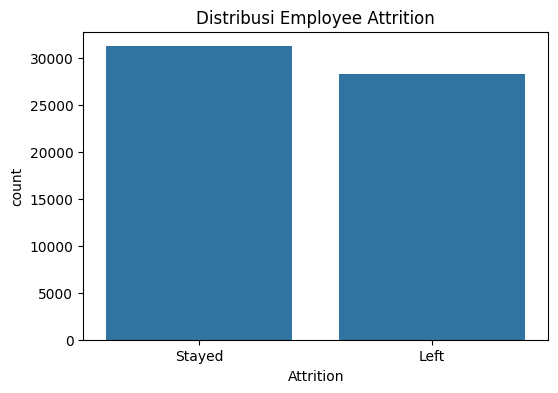

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Attrition'
)

plt.title('Distribusi Employee Attrition')
plt.show()

In [14]:
print(train_df['Attrition'].value_counts())
print(train_df['Attrition'].value_counts(normalize=True)*100)

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


## Numerical Feature Analysis

In [15]:
numerical_cols = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Company Tenure',
    'Number of Dependents'
]

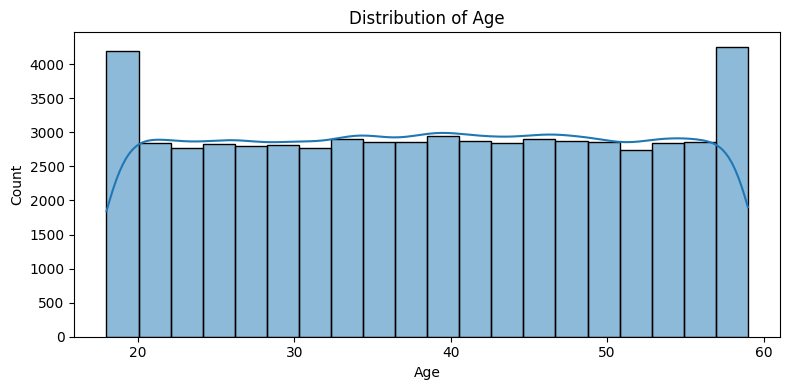

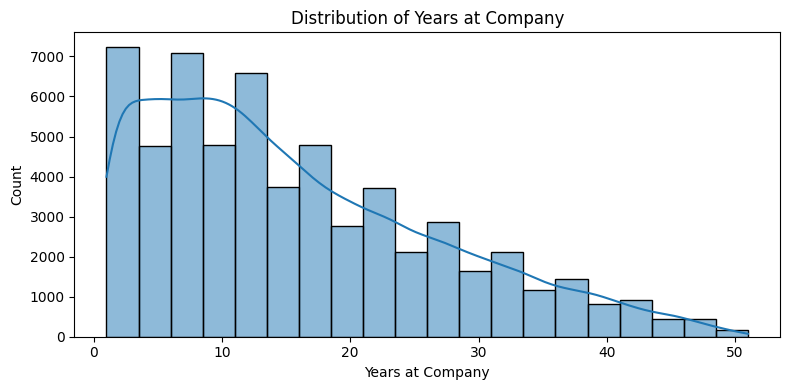

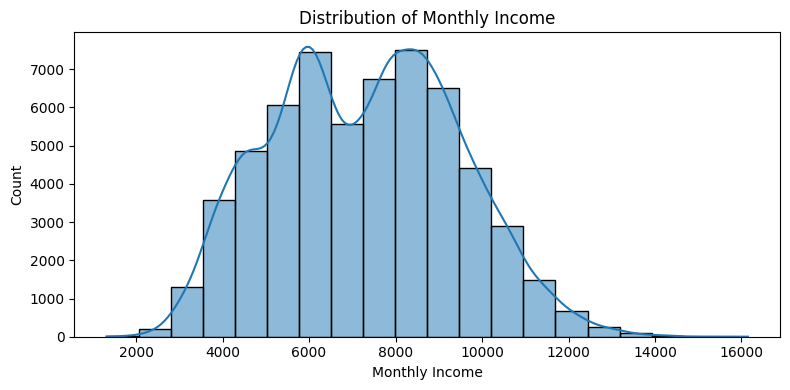

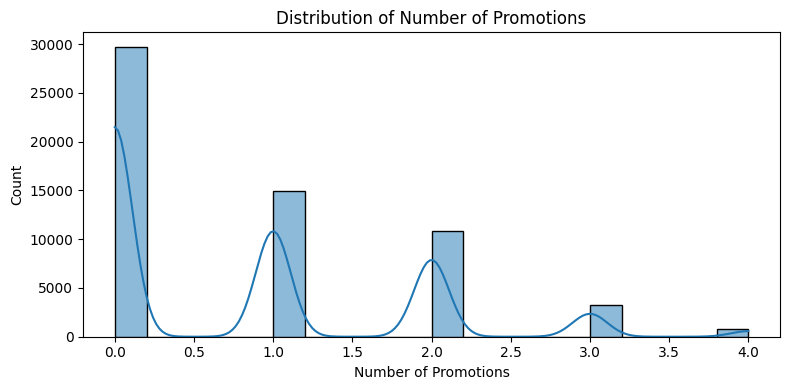

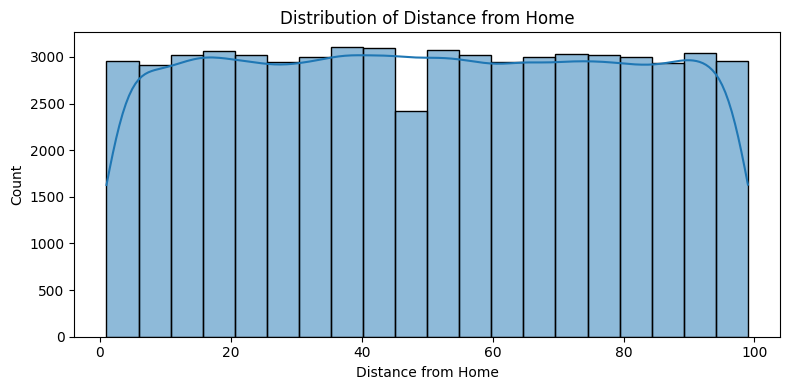

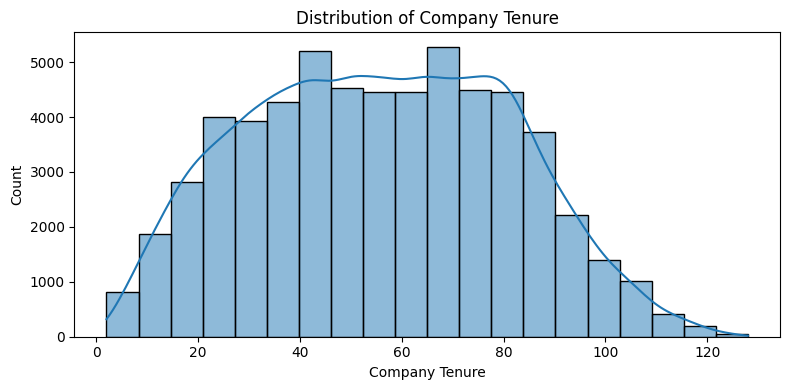

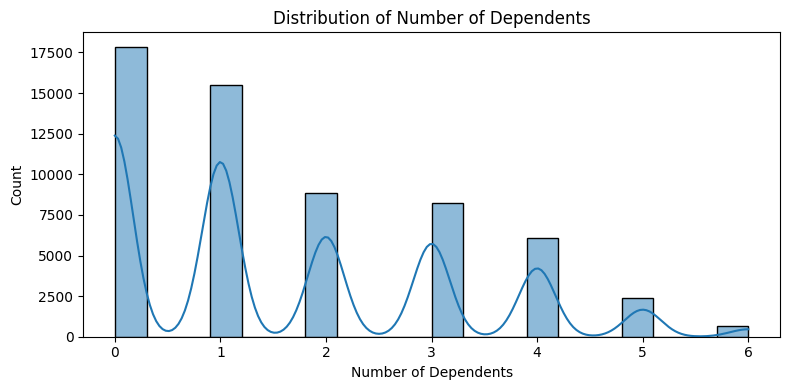

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=train_df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Categorical Feature Analysis

In [17]:
categorical_cols = [
    'Gender',
    'Job Role',
    'Work-Life Balance',
    'Job Satisfaction',
    'Performance Rating',
    'Overtime',
    'Education Level',
    'Marital Status',
    'Job Level',
    'Company Size',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'Company Reputation',
    'Employee Recognition'
]

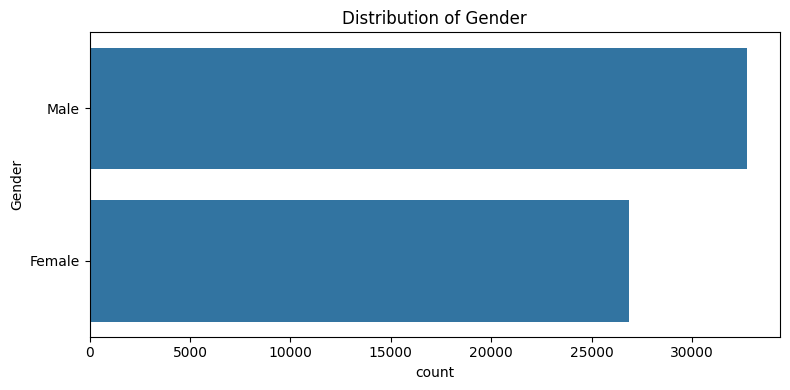

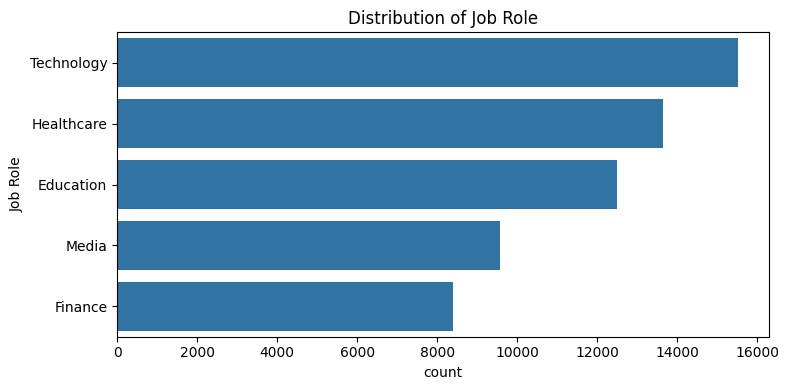

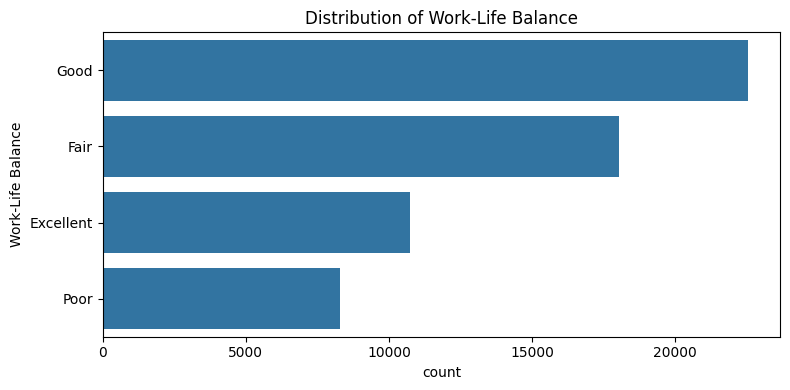

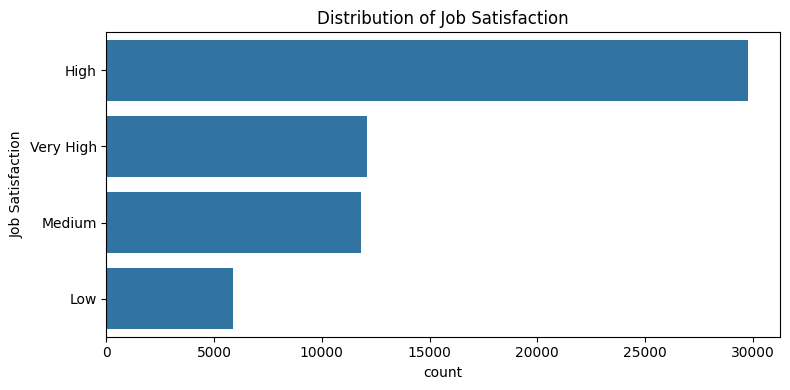

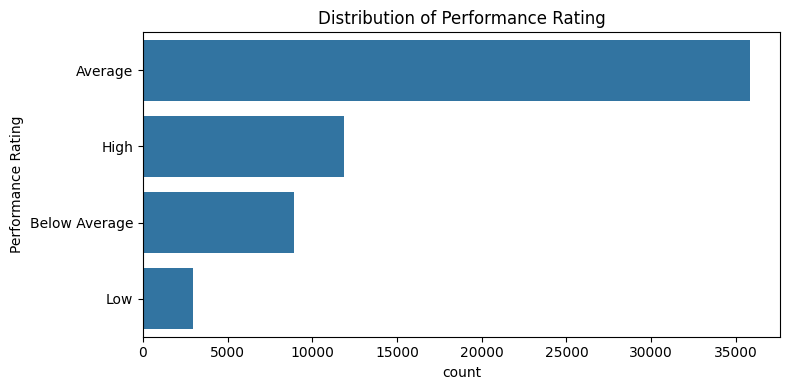

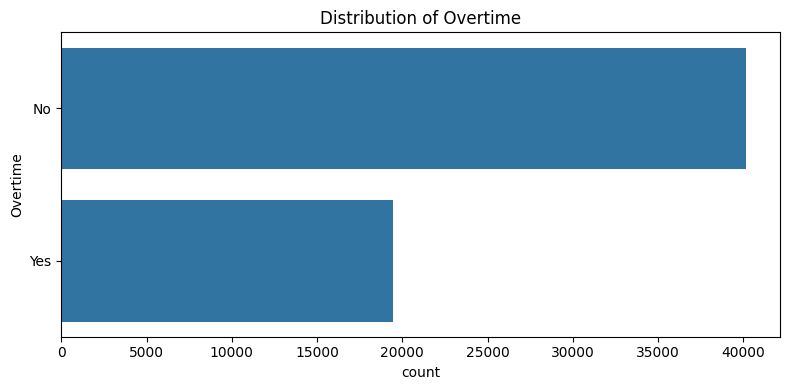

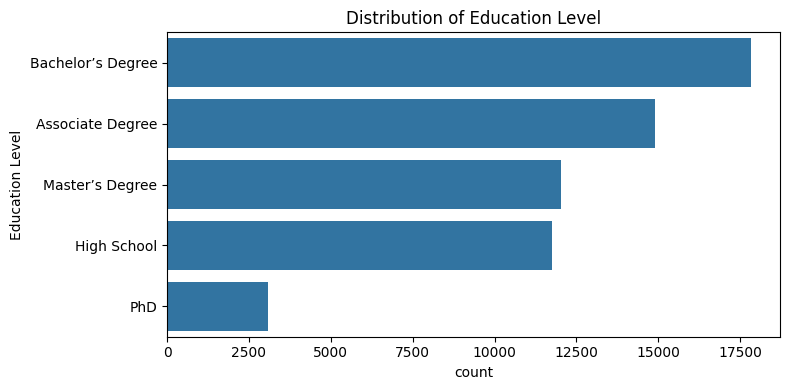

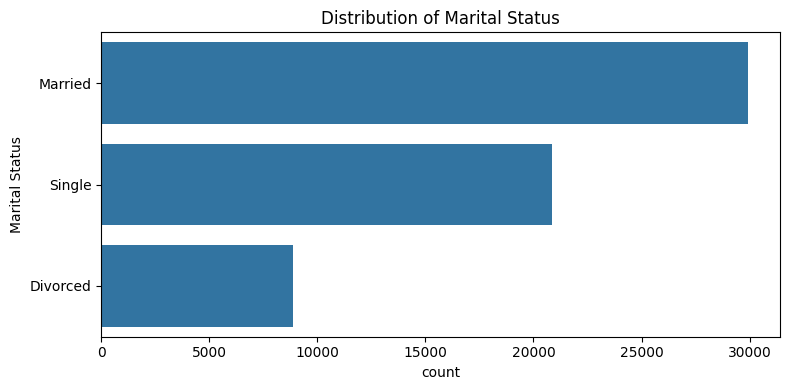

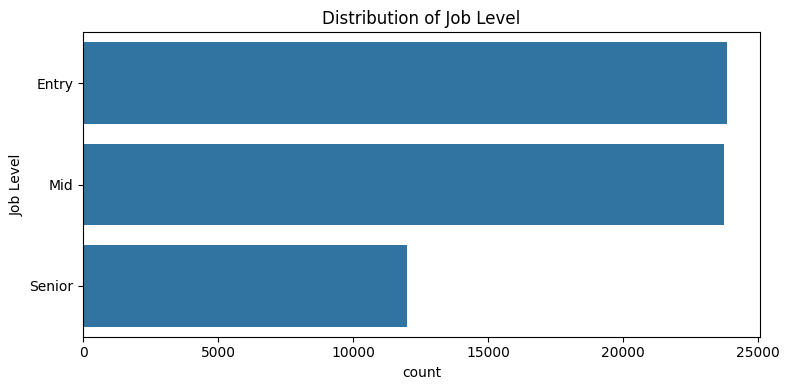

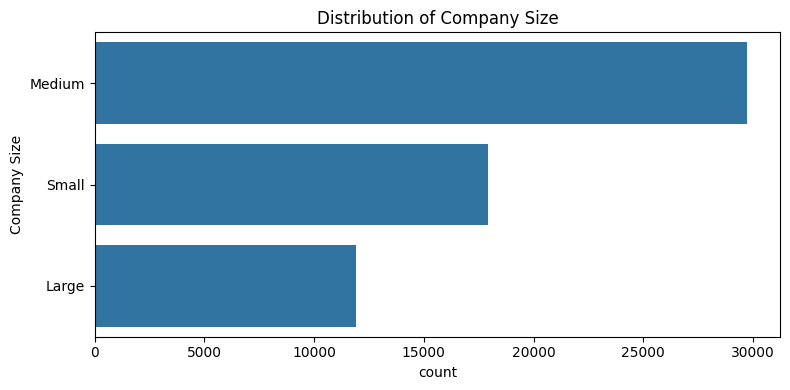

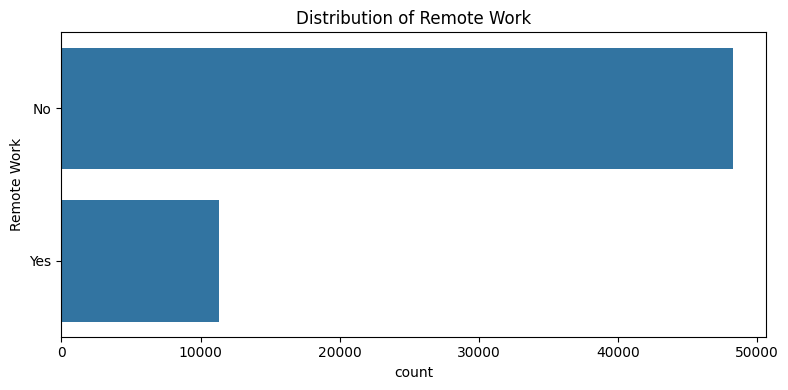

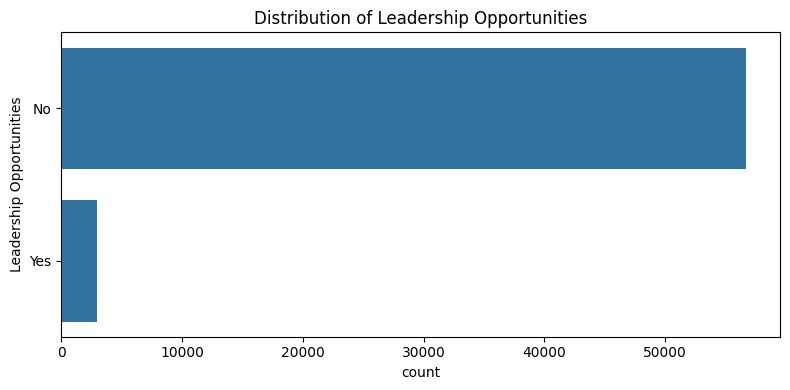

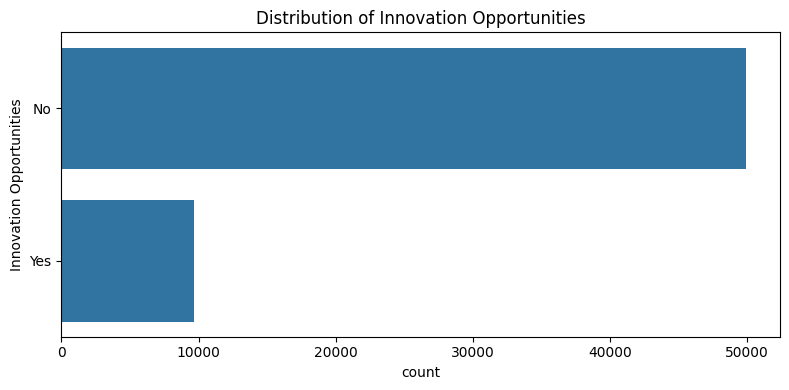

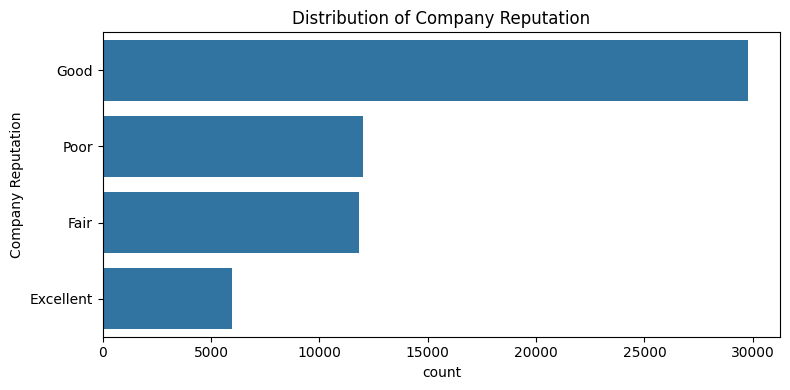

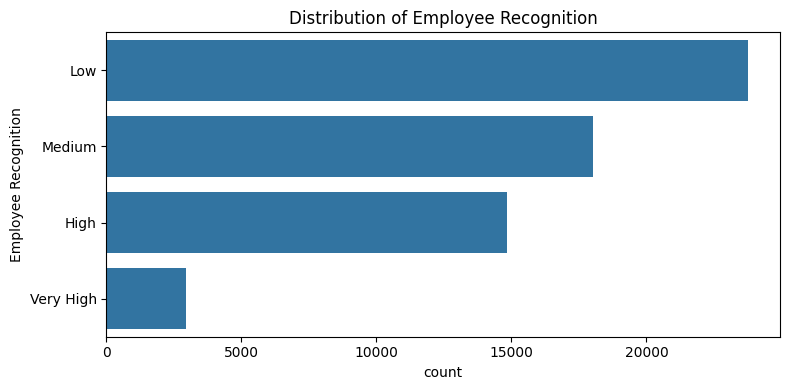

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train_df,
        y=col,
        order=train_df[col].value_counts().index
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Feature-Target Relationships

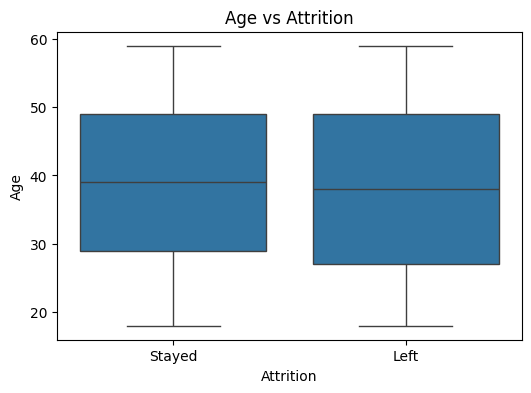

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Age'
)

plt.title('Age vs Attrition')
plt.show()

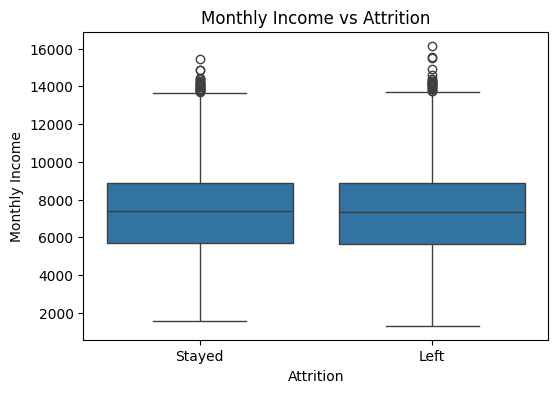

In [20]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Monthly Income'
)

plt.title('Monthly Income vs Attrition')
plt.show()

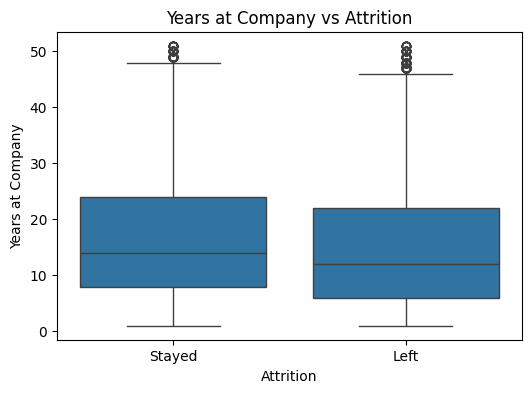

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Years at Company'
)

plt.title('Years at Company vs Attrition')
plt.show()

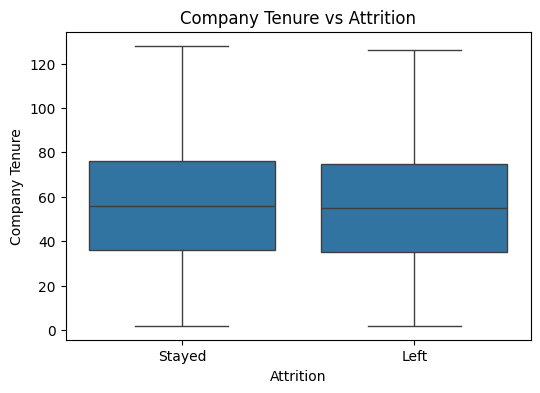

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Company Tenure'
)

plt.title('Company Tenure vs Attrition')
plt.show()

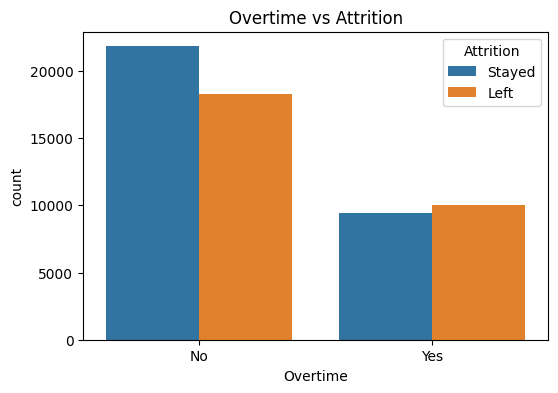

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Overtime',
    hue='Attrition'
)

plt.title('Overtime vs Attrition')
plt.show()

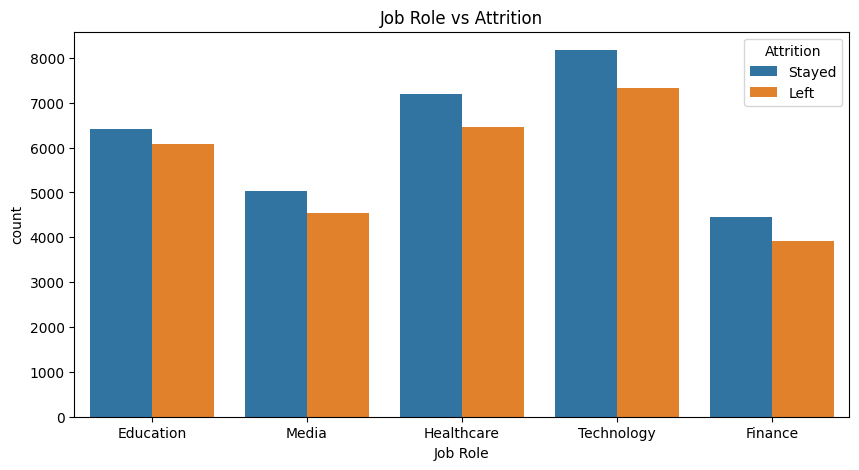

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x='Job Role',
    hue='Attrition'
)

plt.title('Job Role vs Attrition')
plt.show()

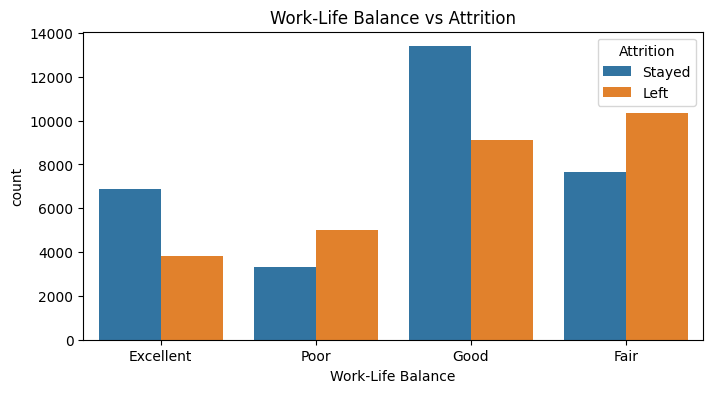

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Work-Life Balance',
    hue='Attrition'
)

plt.title('Work-Life Balance vs Attrition')
plt.show()

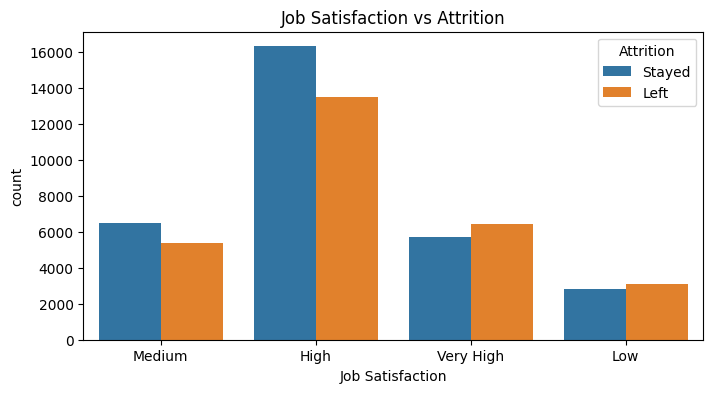

In [26]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Job Satisfaction',
    hue='Attrition'
)

plt.title('Job Satisfaction vs Attrition')
plt.show()

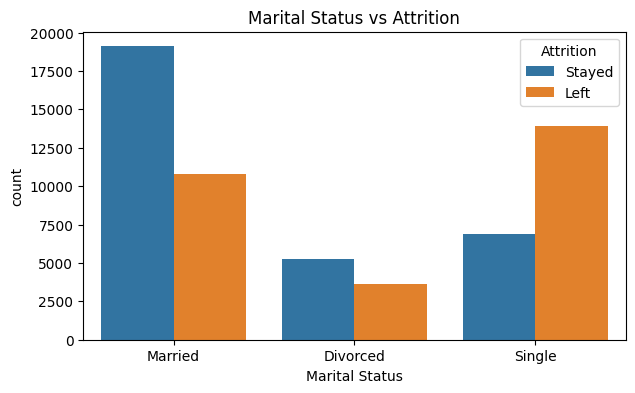

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=train_df,
    x='Marital Status',
    hue='Attrition'
)

plt.title('Marital Status vs Attrition')
plt.show()

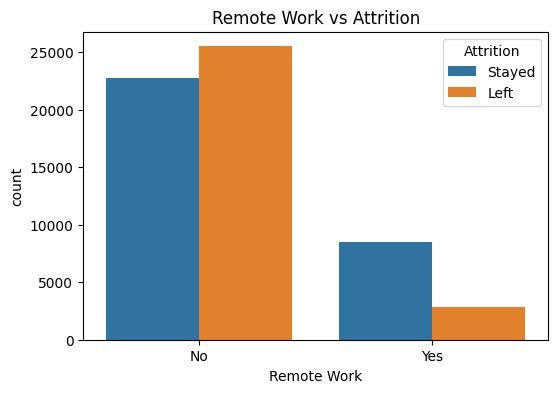

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Remote Work',
    hue='Attrition'
)

plt.title('Remote Work vs Attrition')
plt.show()

## Heatmap (Correlation Matrix)

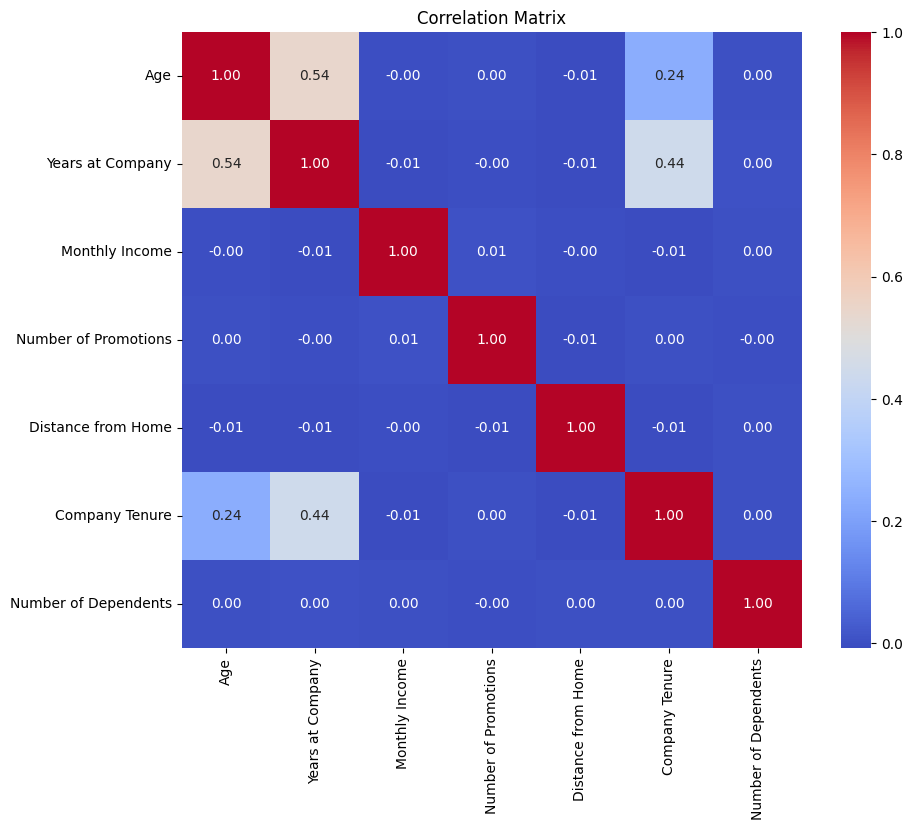

In [29]:
plt.figure(figsize=(10,8))

corr = train_df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

## Drop "Employee ID" Feature

In [30]:
train_df = train_df.drop(columns=['Employee ID'])
test_df = test_df.drop(columns=['Employee ID'])

## Encode Target Variable

In [31]:
mapping = {
    'Stayed': 0,
    'Left': 1
}

In [32]:
train_df['Attrition'] = train_df['Attrition'].map(mapping)
test_df['Attrition'] = test_df['Attrition'].map(mapping)

## Feature and Target Separation

In [33]:
X = train_df.drop(columns=['Attrition'])
y = train_df['Attrition']

In [34]:
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition']

## Data Splitting

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Encode Categorical Features

In [36]:
onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'
)

In [37]:
onehot_encoder.fit(X_train[categorical_cols])

X_train_categorical = onehot_encoder.fit_transform(X_train[categorical_cols])
X_val_categorical = onehot_encoder.transform(X_val[categorical_cols])
X_test_categorical = onehot_encoder.transform(X_test[categorical_cols])

In [38]:
encoded_cols = onehot_encoder.get_feature_names_out(categorical_cols)

In [39]:
X_train_categorical_df = pd.DataFrame(
    X_train_categorical,
    columns=encoded_cols,
    index=X_train.index
)

X_val_categorical_df = pd.DataFrame(
    X_val_categorical,
    columns=encoded_cols,
    index=X_val.index
)

X_test_categorical_df = pd.DataFrame(
    X_test_categorical,
    columns=encoded_cols,
    index=X_test.index
)

## Feature Normalization

In [40]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

StandardScaler()

In [41]:
X_train_numerical_scaled = scaler.transform(X_train[numerical_cols])
X_val_numerical_scaled = scaler.transform(X_val[numerical_cols])
X_test_numerical_scaled = scaler.transform(X_test[numerical_cols])

In [42]:
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_cols, index=X_train.index)
X_val_numerical_scaled_df = pd.DataFrame(X_val_numerical_scaled, columns=numerical_cols, index=X_val.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_cols, index=X_test.index)

## Merge Dataset

In [43]:
X_train_scaled = pd.concat([X_train_numerical_scaled_df, X_train_categorical_df], axis=1)
X_val_scaled = pd.concat([X_val_numerical_scaled_df, X_val_categorical_df], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled_df, X_test_categorical_df], axis=1)

In [44]:
all_processed_cols = X_train_scaled.columns.union(X_train_scaled.columns)

In [45]:
X_train_scaled = X_train_scaled.reindex(columns=all_processed_cols, fill_value=0)
X_val_scaled = X_val_scaled.reindex(columns=all_processed_cols, fill_value=0)
X_test_scaled = X_test_scaled.reindex(columns=all_processed_cols, fill_value=0)

In [46]:
display(X_train_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
9111,0.864674,1.181430,-1.101434,-0.838599,0.035111,0.837133,-0.415406,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
39671,0.616335,-1.134449,0.307412,0.164857,-1.191999,0.915906,0.869261,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
38691,1.195793,1.092358,-0.718217,2.171770,-1.016698,0.758361,-0.415406,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
40509,0.699115,-0.510943,-1.591488,2.171770,0.000051,1.270380,-0.415406,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
54406,0.781894,0.023491,0.138797,2.171770,0.876558,0.600817,2.153928,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [47]:
display(X_val_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
51025,0.533555,-0.154654,1.229921,0.164857,-0.105130,1.230994,-1.057739,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
39466,1.444132,-1.223521,0.069121,0.164857,-0.595974,0.994678,1.511594,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
40843,-1.370377,-0.956304,-1.333687,3.175226,0.140292,0.837133,-0.415406,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48712,0.119657,0.646997,1.226670,-0.838599,0.841498,1.152222,-1.057739,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
56753,0.533555,0.914214,1.618713,-0.838599,-1.682844,-0.541379,0.869261,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [48]:
display(X_test_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.211462,-0.243726,0.337605,0.164857,1.157041,-1.329100,-0.415406,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.294241,-0.778160,-1.272372,0.164857,0.175352,-1.132169,1.511594,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.947454,-0.778160,-0.798576,2.171770,-1.262120,0.797747,0.226928,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.609691,2.517514,-0.825518,-0.838599,-0.245371,1.585468,1.511594,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.036877,0.736069,-1.253327,-0.838599,-0.105130,-0.423220,2.796261,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Feature Selection (ANOVA)

In [49]:
k = 25

In [50]:
selector_anova = SelectKBest(score_func=f_classif, k=k)
selector_anova.fit(X_train_scaled, y_train)

selected_features = X_train_scaled.columns[selector_anova.get_support()]

In [51]:
X_train_selected = pd.DataFrame(
    selector_anova.transform(X_train_scaled),
    columns=selected_features,
    index=X_train_scaled.index
)

X_val_selected = pd.DataFrame(
    selector_anova.transform(X_val_scaled),
    columns=selected_features,
    index=X_val_scaled.index
)

X_test_selected = pd.DataFrame(
    selector_anova.transform(X_test_scaled),
    columns=selected_features,
    index=X_test_scaled.index
)

In [52]:
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'ANOVA Score': selector_anova.scores_[selector_anova.get_support()]
}).sort_values(by='ANOVA Score', ascending=False)

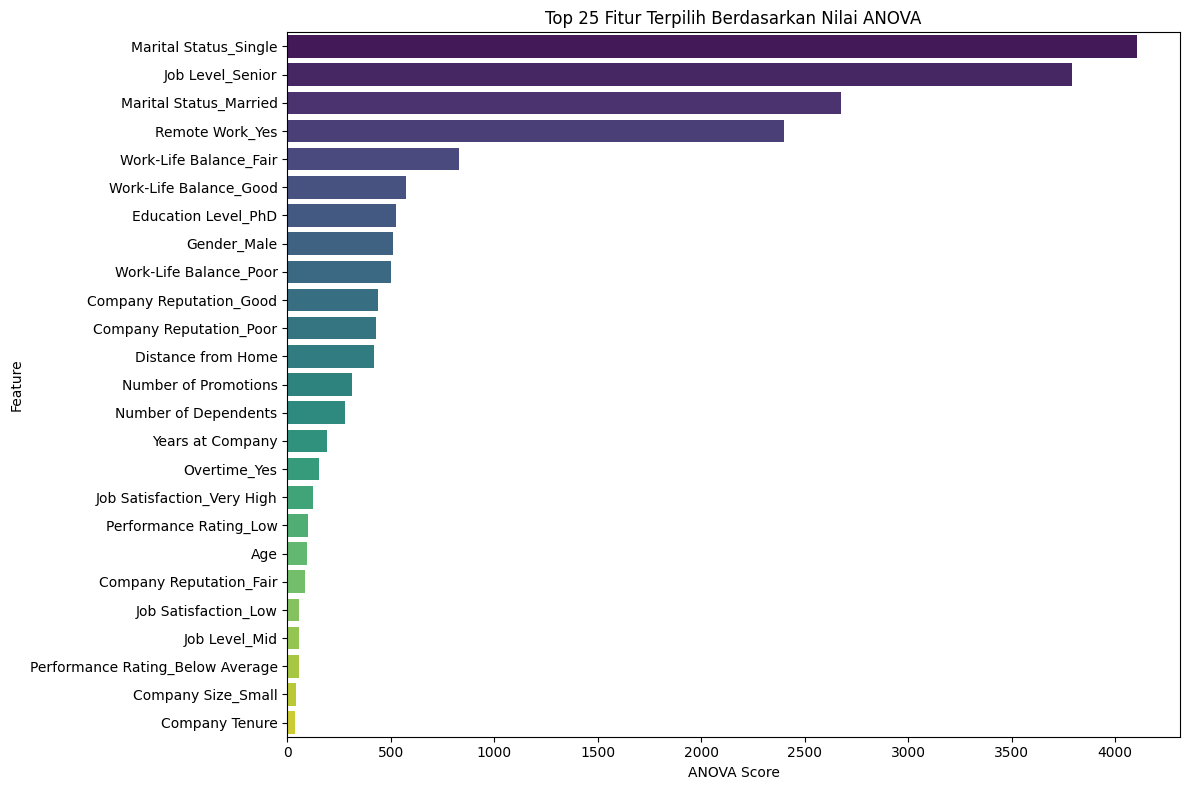

In [53]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_scores.head(25),
    x='ANOVA Score',
    y='Feature',
    palette='viridis'
)
plt.title('Top 25 Fitur Terpilih Berdasarkan Nilai ANOVA')
plt.xlabel('ANOVA Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Implemented Models

In [54]:
model_names = ['KNN', 'Naive Bayes', 'Random Forest']

# Scenario 1: *Baseline Models + Raw Data*

## Scenario 1 Dataset Preparation

In [55]:
X_train_s1 = pd.concat([X_train[numerical_cols], X_train_categorical_df], axis=1)
X_val_s1 = pd.concat([X_val[numerical_cols], X_val_categorical_df], axis=1)

In [56]:
all_cols_s1 = X_train_s1.columns.union(X_val_s1.columns)

In [57]:
X_train_s1 = X_train_s1.reindex(columns=all_cols_s1, fill_value=0)
X_val_s1 = X_val_s1.reindex(columns=all_cols_s1, fill_value=0)

In [58]:
y_train_s1 = y_train.copy()
y_val_s1 = y_val.copy()

## KNN Baseline

In [59]:
knn = KNeighborsClassifier(n_neighbors=5)

In [60]:
knn.fit(X_train_s1, y_train_s1)
y_pred_knn_s1 = knn.predict(X_val_s1)

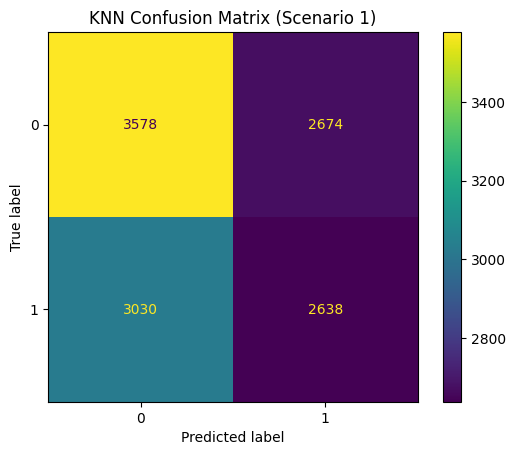

In [61]:
cm_knn_s1 = confusion_matrix(y_val_s1, y_pred_knn_s1)
ConfusionMatrixDisplay(cm_knn_s1).plot()
plt.title('KNN Confusion Matrix (Scenario 1)')
plt.show()

In [62]:
accuracy_knn_s1 = accuracy_score(y_val_s1, y_pred_knn_s1)
precision_knn_s1 = precision_score(y_val_s1, y_pred_knn_s1)
recall_knn_s1 = recall_score(y_val_s1, y_pred_knn_s1)
f1_knn_s1 = f1_score(y_val_s1, y_pred_knn_s1)

print(f"KNN Accuracy (Scenario 1): {accuracy_knn_s1:.4f}")
print(f"KNN Precision (Scenario 1): {precision_knn_s1:.4f}")
print(f"KNN Recall (Scenario 1): {recall_knn_s1:.4f}")
print(f"KNN F1-score (Scenario 1): {f1_knn_s1:.4f}")

KNN Accuracy (Scenario 1): 0.5215
KNN Precision (Scenario 1): 0.4966
KNN Recall (Scenario 1): 0.4654
KNN F1-score (Scenario 1): 0.4805


## Naive Bayes Baseline

In [63]:
nb = GaussianNB()

In [64]:
nb.fit(X_train_s1, y_train_s1)
y_pred_nb_s1 = nb.predict(X_val_s1)

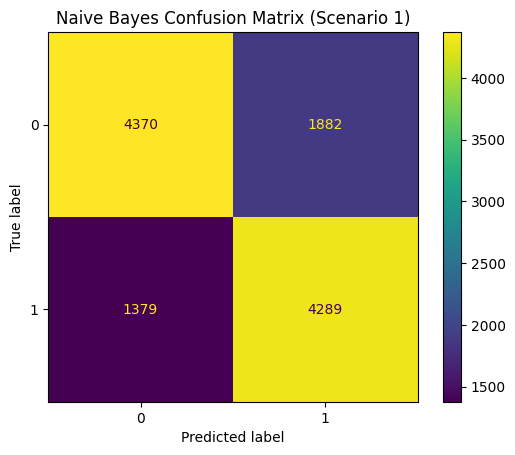

In [65]:
cm_nb_s1 = confusion_matrix(y_val_s1, y_pred_nb_s1)
ConfusionMatrixDisplay(cm_nb_s1).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 1)')
plt.show()

In [66]:
accuracy_nb_s1 = accuracy_score(y_val_s1, y_pred_nb_s1)
precision_nb_s1 = precision_score(y_val_s1, y_pred_nb_s1)
recall_nb_s1 = recall_score(y_val_s1, y_pred_nb_s1)
f1_nb_s1 = f1_score(y_val_s1, y_pred_nb_s1)

print(f"Naive Bayes Accuracy (Scenario 1): {accuracy_nb_s1:.4f}")
print(f"Naive Bayes Precision (Scenario 1): {precision_nb_s1:.4f}")
print(f"Naive Bayes Recall (Scenario 1): {recall_nb_s1:.4f}")
print(f"Naive Bayes F1-score (Scenario 1): {f1_nb_s1:.4f}")

Naive Bayes Accuracy (Scenario 1): 0.7264
Naive Bayes Precision (Scenario 1): 0.6950
Naive Bayes Recall (Scenario 1): 0.7567
Naive Bayes F1-score (Scenario 1): 0.7246


## Random Forest Baseline

In [67]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [68]:
rf.fit(X_train_s1, y_train_s1)
y_pred_rf_s1 = rf.predict(X_val_s1)

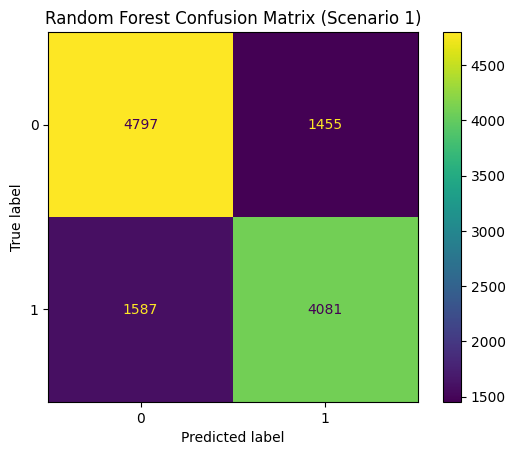

In [69]:
cm_rf_s1 = confusion_matrix(y_val_s1, y_pred_rf_s1)
ConfusionMatrixDisplay(cm_rf_s1).plot()
plt.title('Random Forest Confusion Matrix (Scenario 1)')
plt.show()

In [70]:
accuracy_rf_s1 = accuracy_score(y_val_s1, y_pred_rf_s1)
precision_rf_s1 = precision_score(y_val_s1, y_pred_rf_s1)
recall_rf_s1 = recall_score(y_val_s1, y_pred_rf_s1)
f1_rf_s1 = f1_score(y_val_s1, y_pred_rf_s1)

print(f"Random Forest Accuracy (Scenario 1): {accuracy_rf_s1:.4f}")
print(f"Random Forest Precision (Scenario 1): {precision_rf_s1:.4f}")
print(f"Random Forest Recall (Scenario 1): {recall_rf_s1:.4f}")
print(f"Random Forest F1-score (Scenario 1): {f1_rf_s1:.4f}")

Random Forest Accuracy (Scenario 1): 0.7448
Random Forest Precision (Scenario 1): 0.7372
Random Forest Recall (Scenario 1): 0.7200
Random Forest F1-score (Scenario 1): 0.7285


## Scenario 1 Comparison

In [71]:
performance_metrics_s1 = [
    ['KNN', accuracy_knn_s1, precision_knn_s1, recall_knn_s1, f1_knn_s1],
    ['Naive Bayes', accuracy_nb_s1, precision_nb_s1, recall_nb_s1, f1_nb_s1],
    ['Random Forest', accuracy_rf_s1, precision_rf_s1, recall_rf_s1, f1_rf_s1]
]

metrics_s1_df = pd.DataFrame(
    performance_metrics_s1,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

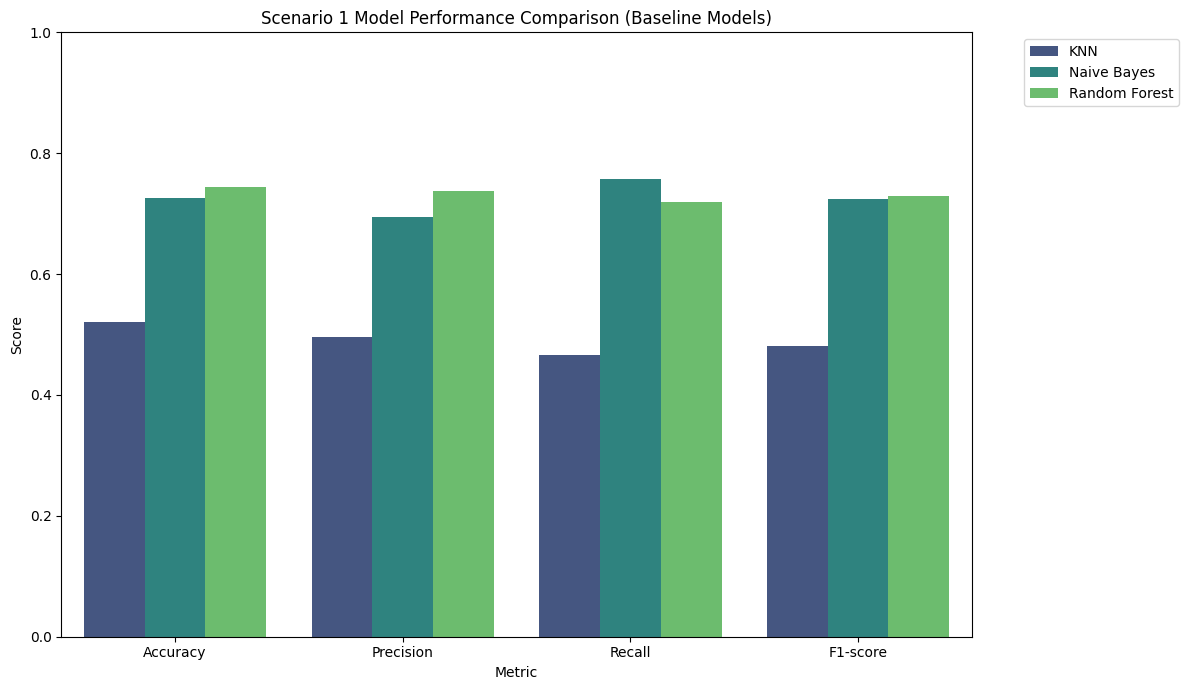

In [72]:
metrics_s1_df_melted = metrics_s1_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s1_df_melted,
    palette='viridis'
)
plt.title('Scenario 1 Model Performance Comparison (Baseline Models)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 2: *Baseline Models + Normalization*

## Scenario 2 Dataset Preparation

In [ ]:
X_train_s2 = X_train_scaled.copy()
X_val_s2 = X_val_scaled.copy()

In [ ]:
y_train_s2 = y_train.copy()
y_val_s2 = y_val.copy()

## KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(X_train_s2, y_train_s2)
y_pred_knn_s2 = knn.predict(X_val_s2)

In [ ]:
cm_knn_s2 = confusion_matrix(y_val_s2, y_pred_knn_s2)
ConfusionMatrixDisplay(cm_knn_s2).plot()
plt.title('KNN Confusion Matrix (Scenario 2)')
plt.show()

In [ ]:
accuracy_knn_s2 = accuracy_score(y_val_s2, y_pred_knn_s2)
precision_knn_s2 = precision_score(y_val_s2, y_pred_knn_s2)
recall_knn_s2 = recall_score(y_val_s2, y_pred_knn_s2)
f1_knn_s2 = f1_score(y_val_s2, y_pred_knn_s2)

print(f"KNN Accuracy (Scenario 2): {accuracy_knn_s2:.4f}")
print(f"KNN Precision (Scenario 2): {precision_knn_s2:.4f}")
print(f"KNN Recall (Scenario 2): {recall_knn_s2:.4f}")
print(f"KNN F1-score (Scenario 2): {f1_knn_s2:.4f}")

## Naive Bayes

In [ ]:
nb = GaussianNB()

In [ ]:
nb.fit(X_train_s2, y_train_s2)
y_pred_nb_s2 = nb.predict(X_val_s2)

In [ ]:
cm_nb_s2 = confusion_matrix(y_val_s2, y_pred_nb_s2)
ConfusionMatrixDisplay(cm_nb_s2).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 2)')
plt.show()

In [ ]:
accuracy_nb_s2 = accuracy_score(y_val_s2, y_pred_nb_s2)
precision_nb_s2 = precision_score(y_val_s2, y_pred_nb_s2)
recall_nb_s2 = recall_score(y_val_s2, y_pred_nb_s2)
f1_nb_s2 = f1_score(y_val_s2, y_pred_nb_s2)

print(f"Naive Bayes Accuracy (Scenario 2): {accuracy_nb_s2:.4f}")
print(f"Naive Bayes Precision (Scenario 2): {precision_nb_s2:.4f}")
print(f"Naive Bayes Recall (Scenario 2): {recall_nb_s2:.4f}")
print(f"Naive Bayes F1-score (Scenario 2): {f1_nb_s2:.4f}")

## Random Forest

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(X_train_s2, y_train_s2)
y_pred_rf_s2 = rf.predict(X_val_s2)

In [ ]:
cm_rf_s2 = confusion_matrix(y_val_s2, y_pred_rf_s2)
ConfusionMatrixDisplay(cm_rf_s2).plot()
plt.title('Random Forest Confusion Matrix (Scenario 2)')
plt.show()

In [ ]:
accuracy_rf_s2 = accuracy_score(y_val_s2, y_pred_rf_s2)
precision_rf_s2 = precision_score(y_val_s2, y_pred_rf_s2)
recall_rf_s2 = recall_score(y_val_s2, y_pred_rf_s2)
f1_rf_s2 = f1_score(y_val_s2, y_pred_rf_s2)

print(f"Random Forest Accuracy (Scenario 2): {accuracy_rf_s2:.4f}")
print(f"Random Forest Precision (Scenario 2): {precision_rf_s2:.4f}")
print(f"Random Forest Recall (Scenario 2): {recall_rf_s2:.4f}")
print(f"Random Forest F1-score (Scenario 2): {f1_rf_s2:.4f}")

## Scenario 2 Comparison

In [ ]:
performance_metrics_s2 = [
    ['KNN', accuracy_knn_s2, precision_knn_s2, recall_knn_s2, f1_knn_s2],
    ['Naive Bayes', accuracy_nb_s2, precision_nb_s2, recall_nb_s2, f1_nb_s2],
    ['Random Forest', accuracy_rf_s2, precision_rf_s2, recall_rf_s2, f1_rf_s2]
]

metrics_s2_df = pd.DataFrame(
    performance_metrics_s2,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

In [ ]:
metrics_s2_df_melted = metrics_s2_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s2_df_melted,
    palette='viridis'
)
plt.title('Scenario 2 Model Performance Comparison (Baseline Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

## KNN Parameter

In [ ]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

In [ ]:
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

## Naive Bayes Parameter

In [ ]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

In [ ]:
grid_search_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

## Random Forest Parameter

In [ ]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

In [ ]:
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

# Scenario 3: *Tuned Models + Normalization*

## Scenario 3 Dataset Preparation

In [ ]:
X_train_s3 = X_train_scaled.copy()
X_val_s3 = X_val_scaled.copy()

In [ ]:
y_train_s3 = y_train.copy()
y_val_s3 = y_val.copy()

## Scenario 3 Tuning

### KNN Tuning

In [ ]:
grid_search_knn.fit(X_train_s3, y_train_s3 )

In [ ]:
print("Best Parameters (Scenario 3):")
print(grid_search_knn.best_params_)

### Naive Bayes Tuning

In [ ]:
grid_search_nb.fit(X_train_s3, y_train_s3)

In [ ]:
print("Best Parameters (Scenario 3):")
print(grid_search_nb.best_params_)

### Random Forest Tuning

In [ ]:
random_search_rf.fit(X_train_s3, y_train_s3)

In [ ]:
print("Best Parameters (Scenario 3):")
print(random_search_rf.best_params_)

##  Tuned KNN

In [ ]:
best_knn_s3 = grid_search_knn.best_estimator_

In [ ]:
best_knn_s3.fit(X_train_s3, y_train_s3)
y_pred_knn_s3 = best_knn_s3.predict(X_val_s3)

In [ ]:
cm_knn_s3 = confusion_matrix(y_val_s3, y_pred_knn_s3)
ConfusionMatrixDisplay(cm_knn_s3).plot()
plt.title('KNN Confusion Matrix (Scenario 3)')
plt.show()

In [ ]:
accuracy_knn_s3 = accuracy_score(y_val_s3, y_pred_knn_s3)
precision_knn_s3 = precision_score(y_val_s3, y_pred_knn_s3)
recall_knn_s3 = recall_score(y_val_s3, y_pred_knn_s3)
f1_knn_s3 = f1_score(y_val_s3, y_pred_knn_s3)

print(f"KNN Accuracy (Scenario 3): {accuracy_knn_s3:.4f}")
print(f"KNN Precision (Scenario 3): {precision_knn_s3:.4f}")
print(f"KNN Recall (Scenario 3): {recall_knn_s3:.4f}")
print(f"KNN F1-score (Scenario 3): {f1_knn_s3:.4f}")

## Tuned Naive Bayes

In [ ]:
best_nb_s3 = grid_search_nb.best_estimator_

In [ ]:
best_nb_s3.fit(X_train_s3, y_train_s3)
y_pred_nb_s3 = best_nb_s3.predict(X_val_s3)

In [ ]:
cm_nb_s3 = confusion_matrix(y_val_s3, y_pred_nb_s3)
ConfusionMatrixDisplay(cm_nb_s3).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 3)')
plt.show()

In [ ]:
accuracy_nb_s3 = accuracy_score(y_val_s3, y_pred_nb_s3)
precision_nb_s3 = precision_score(y_val_s3, y_pred_nb_s3)
recall_nb_s3 = recall_score(y_val_s3, y_pred_nb_s3)
f1_nb_s3 = f1_score(y_val_s3, y_pred_nb_s3)

print(f"Naive Bayes Accuracy (Scenario 3): {accuracy_nb_s3:.4f}")
print(f"Naive Bayes Precision (Scenario 3): {precision_nb_s3:.4f}")
print(f"Naive Bayes Recall (Scenario 3): {recall_nb_s3:.4f}")
print(f"Naive Bayes F1-score (Scenario 3): {f1_nb_s3:.4f}")

## Random Forest Feature Selection

In [ ]:
best_rf_s3 = random_search_rf.best_estimator_

In [ ]:
best_rf_s3.fit(X_train_s3, y_train_s3)
y_pred_rf_s3 = best_rf_s3.predict(X_val_s3)

In [ ]:
cm_rf_s3 = confusion_matrix(y_val_s3, y_pred_rf_s3)
ConfusionMatrixDisplay(cm_rf_s3).plot()
plt.title('Random Forest Confusion Matrix (Scenario 3)')
plt.show()

In [ ]:
accuracy_rf_s3 = accuracy_score(y_val_s3, y_pred_rf_s3)
precision_rf_s3 = precision_score(y_val_s3, y_pred_rf_s3)
recall_rf_s3 = recall_score(y_val_s3, y_pred_rf_s3)
f1_rf_s3 = f1_score(y_val_s3, y_pred_rf_s3)

print(f"Random Forest Accuracy (Scenario 3): {accuracy_rf_s3:.4f}")
print(f"Random Forest Precision (Scenario 3): {precision_rf_s3:.4f}")
print(f"Random Forest Recall (Scenario 3): {recall_rf_s3:.4f}")
print(f"Random Forest F1-score (Scenario 3): {f1_rf_s3:.4f}")

## Scenario 3 Comparison

In [ ]:
performance_metrics_s3 = [
    ['KNN', accuracy_knn_s3, precision_knn_s3, recall_knn_s3, f1_knn_s3],
    ['Naive Bayes', accuracy_nb_s3, precision_nb_s3, recall_nb_s3, f1_nb_s3],
    ['Random Forest', accuracy_rf_s3, precision_rf_s3, recall_rf_s3, f1_rf_s3]
]

metrics_s3_df = pd.DataFrame(
    performance_metrics_s3,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

In [ ]:
metrics_s3_df_melted = metrics_s3_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s3_df_melted,
    palette='viridis'
)
plt.title('Scenario 3 Model Performance Comparison (Tuned Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 4: *Tuned Models + Normalization + Feature Selection*

## Scenario 4 Dataset Preparation

In [ ]:
X_train_s4 = X_train_selected.copy()
X_val_s4 = X_val_selected.copy()

In [ ]:
y_train_s4 = y_train.copy()
y_val_s4 = y_val.copy()

## Scenario 4 Tuning

### KNN Tuning

In [ ]:
grid_search_knn.fit(X_train_s4, y_train_s4 )

In [ ]:
print("Best Parameters (Scenario 4):")
print(grid_search_knn.best_params_)

### Naive Bayes Tuning

In [ ]:
grid_search_nb.fit(X_train_s4, y_train_s4)

In [ ]:
print("Best Parameters (Scenario 4):")
print(grid_search_nb.best_params_)

### Random Forest Tuning

In [ ]:
random_search_rf.fit(X_train_s4, y_train_s4)

In [ ]:
print("Best Parameters (Scenario 4):")
print(random_search_rf.best_params_)

## Tuned KNN + Feature Selection

In [ ]:
best_knn_s4 = grid_search_knn.best_estimator_

In [ ]:
best_knn_s4.fit(X_train_s4, y_train_s4)
y_pred_knn_s4 = best_knn_s4.predict(X_val_s4)

In [ ]:
cm_knn_s4 = confusion_matrix(y_val_s4, y_pred_knn_s4)
ConfusionMatrixDisplay(cm_knn_s4).plot()
plt.title('KNN Confusion Matrix (Scenario 4)')
plt.show()

In [ ]:
accuracy_knn_s4 = accuracy_score(y_val_s4, y_pred_knn_s4)
precision_knn_s4 = precision_score(y_val_s4, y_pred_knn_s4)
recall_knn_s4 = recall_score(y_val_s4, y_pred_knn_s4)
f1_knn_s4 = f1_score(y_val_s4, y_pred_knn_s4)

print(f"KNN Accuracy (Scenario 4): {accuracy_knn_s4:.4f}")
print(f"KNN Precision (Scenario 4): {precision_knn_s4:.4f}")
print(f"KNN Recall (Scenario 4): {recall_knn_s4:.4f}")
print(f"KNN F1-score (Scenario 4): {f1_knn_s4:.4f}")

## Tuned Naive Bayes + Feature Selection

In [ ]:
best_nb_s4 = grid_search_nb.best_estimator_

In [ ]:
best_nb_s4.fit(X_train_s4, y_train_s4)
y_pred_nb_s4 = best_nb_s4.predict(X_val_s4)

In [ ]:
cm_nb_s4 = confusion_matrix(y_val_s4, y_pred_nb_s4)
ConfusionMatrixDisplay(cm_nb_s4).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 4)')
plt.show()

In [ ]:
accuracy_nb_s4 = accuracy_score(y_val_s4, y_pred_nb_s4)
precision_nb_s4 = precision_score(y_val_s4, y_pred_nb_s4)
recall_nb_s4 = recall_score(y_val_s4, y_pred_nb_s4)
f1_nb_s4 = f1_score(y_val_s4, y_pred_nb_s4)

print(f"Naive Bayes Accuracy (Scenario 4): {accuracy_nb_s4:.4f}")
print(f"Naive Bayes Precision (Scenario 4): {precision_nb_s4:.4f}")
print(f"Naive Bayes Recall (Scenario 4): {recall_nb_s4:.4f}")
print(f"Naive Bayes F1-score (Scenario 4): {f1_nb_s4:.4f}")

## Tuned Random Forest + Feature Selection

In [ ]:
best_rf_s4 = random_search_rf.best_estimator_

In [ ]:
best_rf_s4.fit(X_train_s4, y_train_s4)
y_pred_rf_s4 = best_rf_s4.predict(X_val_s4)

In [ ]:
cm_rf_s4 = confusion_matrix(y_val_s4, y_pred_rf_s4)
ConfusionMatrixDisplay(cm_rf_s4).plot()
plt.title('Random Forest Confusion Matrix (Scenario 4)')
plt.show()

In [ ]:
accuracy_rf_s4 = accuracy_score(y_val_s4, y_pred_rf_s4)
precision_rf_s4 = precision_score(y_val_s4, y_pred_rf_s4)
recall_rf_s4 = recall_score(y_val_s4, y_pred_rf_s4)
f1_rf_s4 = f1_score(y_val_s4, y_pred_rf_s4)

print(f"Random Forest Accuracy (Scenario 4): {accuracy_rf_s4:.4f}")
print(f"Random Forest Precision (Scenario 4): {precision_rf_s4:.4f}")
print(f"Random Forest Recall (Scenario 4): {recall_rf_s4:.4f}")
print(f"Random Forest F1-score (Scenario 4): {f1_rf_s4:.4f}")

## Scenario 4 Comparison

In [ ]:
performance_metrics_s4 = [
    ['KNN', accuracy_knn_s4, precision_knn_s4, recall_knn_s4, f1_knn_s4],
    ['Naive Bayes', accuracy_nb_s4, precision_nb_s4, recall_nb_s4, f1_nb_s4],
    ['Random Forest', accuracy_rf_s4, precision_rf_s4, recall_rf_s4, f1_rf_s4]
]

metrics_s4_df = pd.DataFrame(
    performance_metrics_s4,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

In [ ]:
metrics_s4_df_melted = metrics_s4_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s4_df_melted,
    palette='viridis'
)
plt.title('Scenario 4 Model Performance Comparison (Tuned Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Overall Comparison

## Comparison Across Scenarios

In [ ]:
metrics_s1_df['Scenario'] = 'Scenario 1'
metrics_s2_df['Scenario'] = 'Scenario 2'
metrics_s3_df['Scenario'] = 'Scenario 3'
metrics_s4_df['Scenario'] = 'Scenario 4'
all_scenarios_df = pd.concat([metrics_s1_df, metrics_s2_df, metrics_s3_df, metrics_s4_df], ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=all_scenarios_df, x='Model', y='F1-score', hue='Scenario')
plt.title('F1-Score Comparison Across All Scenarios')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

display(all_scenarios_df.sort_values(by='F1-score', ascending=False))

## Best Model Selection

In [ ]:
best_model_idx = all_scenarios_df['F1-score'].idxmax()
best_model_row = all_scenarios_df.iloc[best_model_idx]

print(f"Model Terbaik Berdasarkan F1-Score:")
print(f"- Model   : {best_model_row['Model']}")
print(f"- Scenario: {best_model_row['Scenario']}")
print(f"- F1-Score: {best_model_row['F1-score']:.4f}")

# Conclusion

Lorem ipsum dolor sit amet consectetur adipiscing elit. Quisque faucibus ex sapien vitae pellentesque sem placerat. In id cursus mi pretium tellus duis convallis. Tempus leo eu aenean sed diam urna tempor. Pulvinar vivamus fringilla lacus nec metus bibendum egestas. Iaculis massa nisl malesuada lacinia integer nunc posuere. Ut hendrerit semper vel class aptent taciti sociosqu. Ad litora torquent per conubia nostra inceptos himenaeos.

Lorem ipsum dolor sit amet consectetur adipiscing elit. Quisque faucibus ex sapien vitae pellentesque sem placerat. In id cursus mi pretium tellus duis convallis. Tempus leo eu aenean sed diam urna tempor. Pulvinar vivamus fringilla lacus nec metus bibendum egestas. Iaculis massa nisl malesuada lacinia integer nunc posuere. Ut hendrerit semper vel class aptent taciti sociosqu. Ad litora torquent per conubia nostra inceptos himenaeos.

Lorem ipsum dolor sit amet consectetur adipiscing elit. Quisque faucibus ex sapien vitae pellentesque sem placerat. In id cursus mi pretium tellus duis convallis. Tempus leo eu aenean sed diam urna tempor. Pulvinar vivamus fringilla lacus nec metus bibendum egestas. Iaculis massa nisl malesuada lacinia integer nunc posuere. Ut hendrerit semper vel class aptent taciti sociosqu. Ad litora torquent per conubia nostra inceptos himenaeos.